c:\Users\shrin\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\shrin\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

c:\Users\shrin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.



📏 Silhouette Score (UMAP): 0.4152


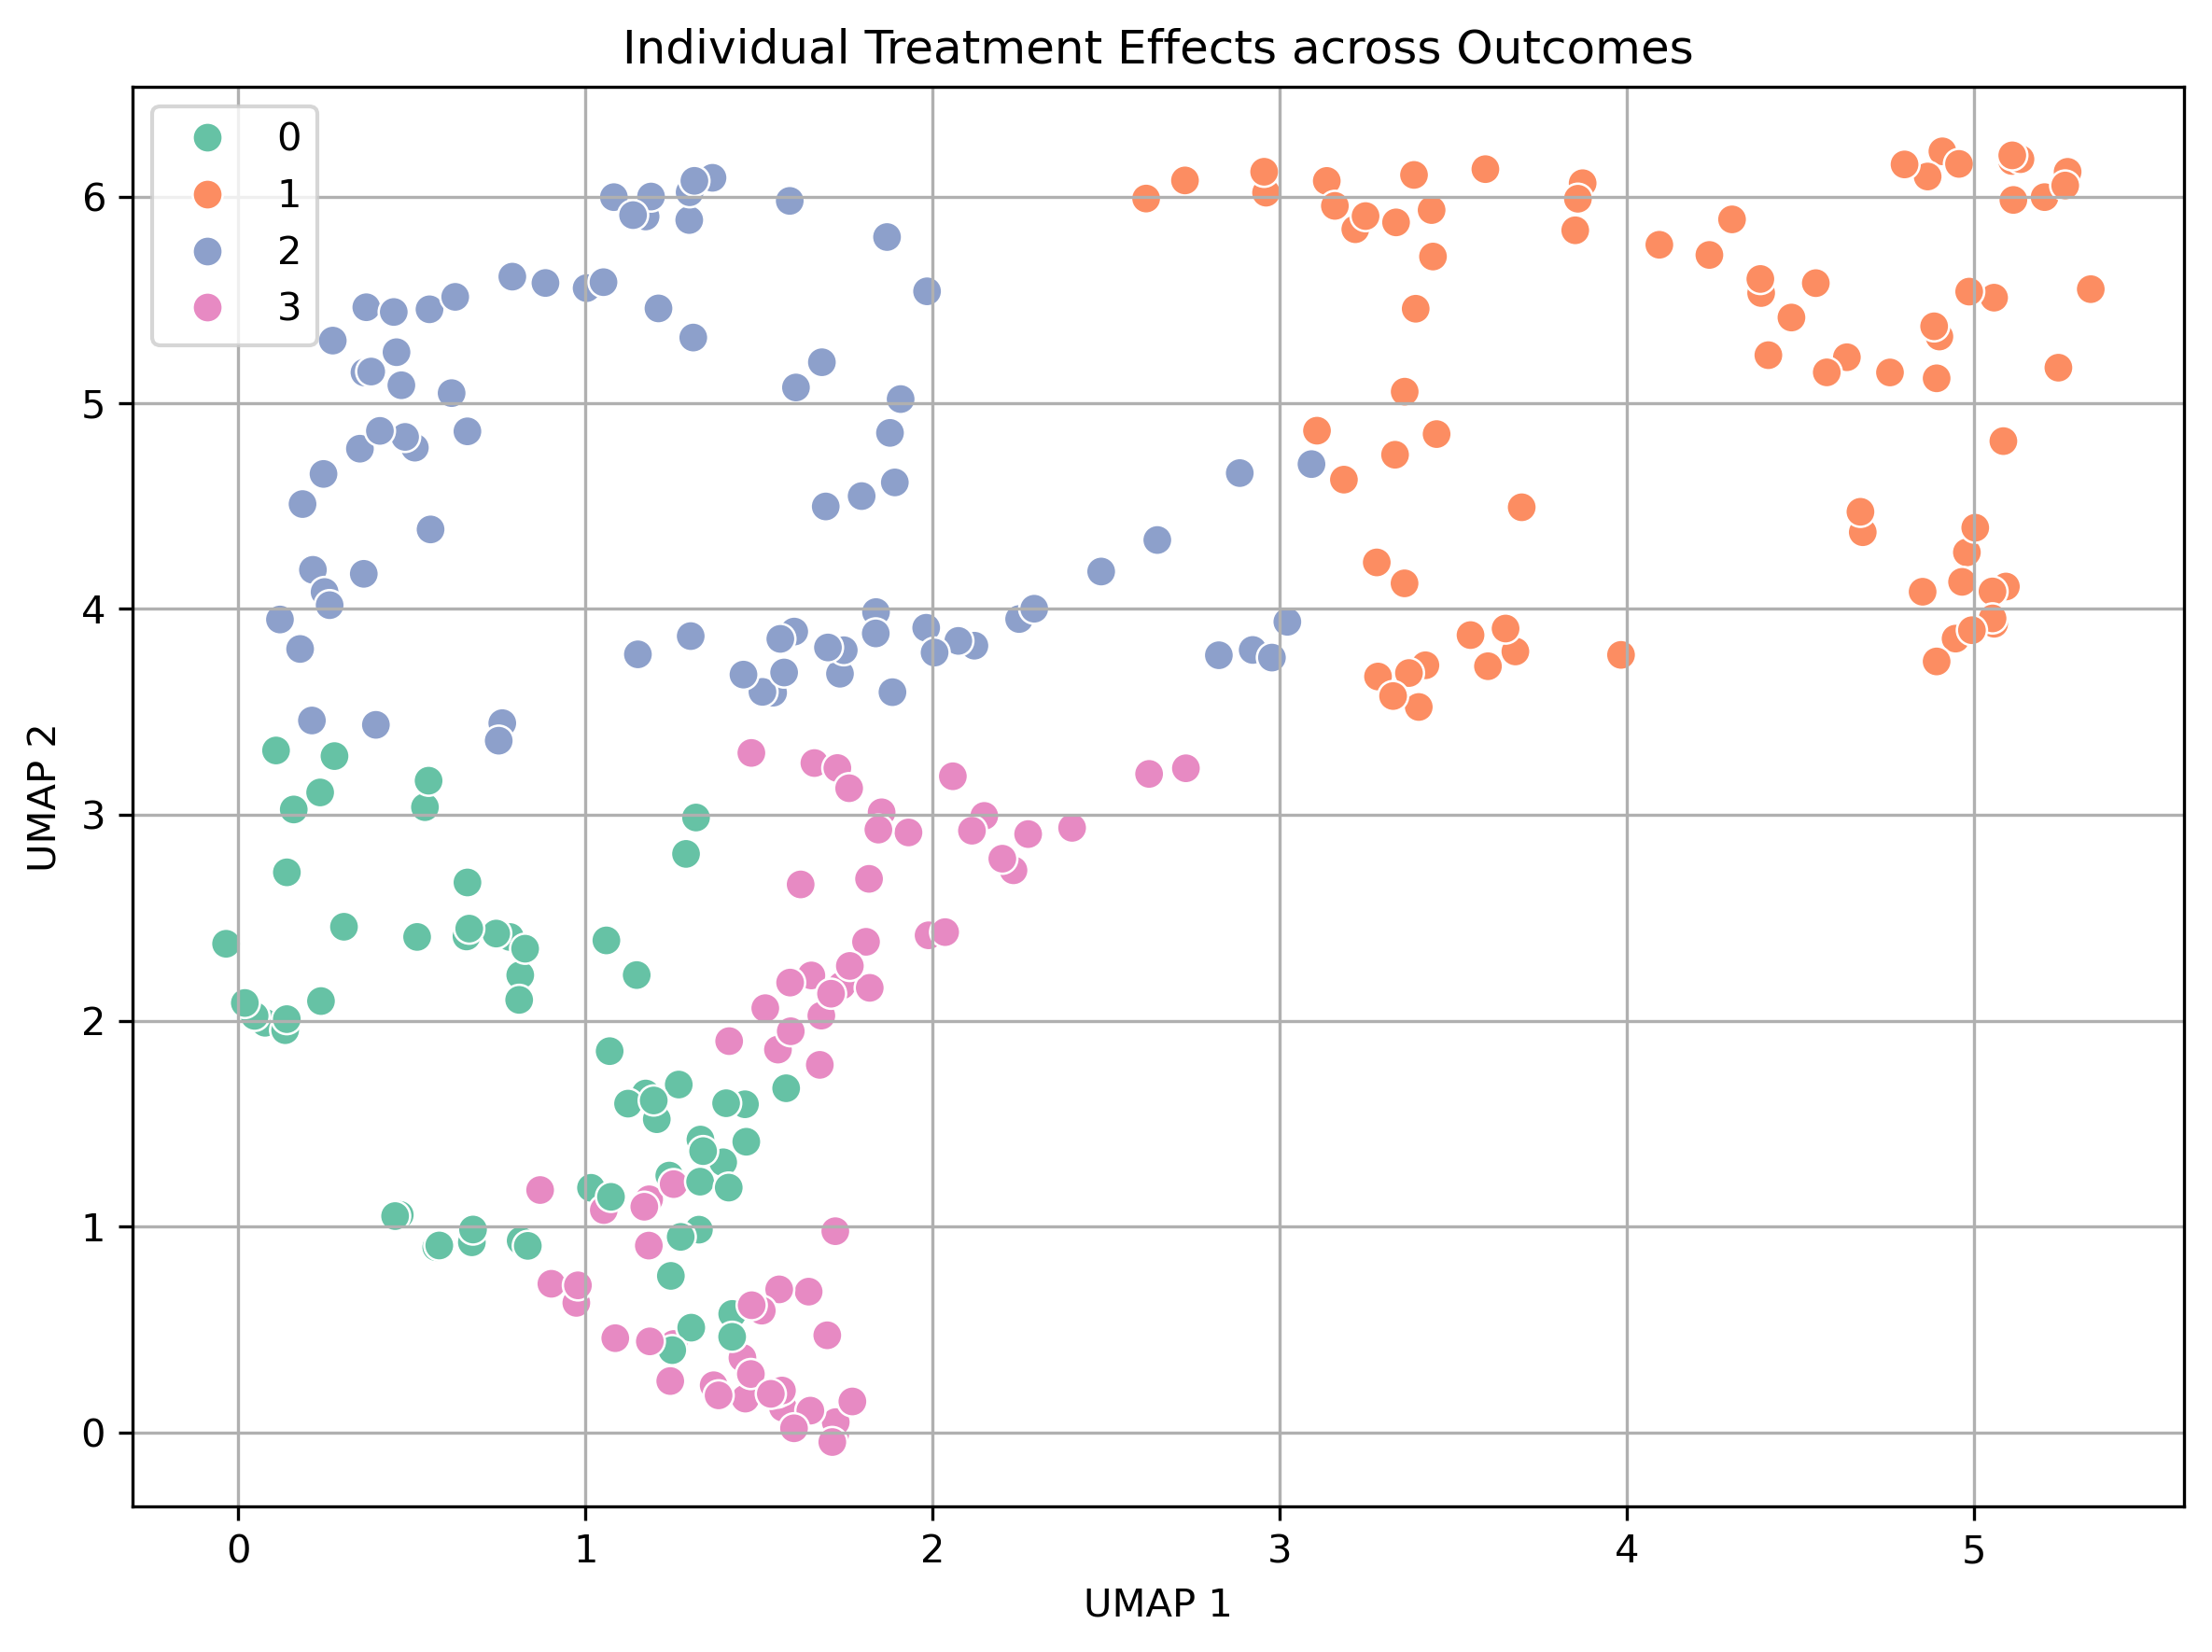

In [30]:
from modules.cluster import generate_cate_matrix, umap_cluster_cates, visualize_clusters, visualize_clusters_3d_plotly, plot_cate_tradeoff
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from modules.preprocess import load_and_clean_data, prepare_variables



# Step 1: prepare baseline
df = load_and_clean_data("ed.csv", ed_daily_path="ed_daily.csv")
X, Y, T, feature_names = prepare_variables(df, outcome_col='vs_clin')  # any outcome will do, X is same

# Step 2: define CATE sources
cate_file_dict = {
    "mrs_binary": "cate_results/cate_results_mrs_binary.csv",
    "infarct_dch": "cate_results/cate_results_infarct_dch.csv",
    "vs_clin": "cate_results/cate_results_vs_clin.csv",
    "infection_dch": "cate_results/cate_results_infection_dch.csv",
    "gos_binary": "cate_results/cate_results_gos_binary.csv",
    "shunt_180": "cate_results/cate_results_shunt_180.csv",
}

# Step 3: build matrix
cate_matrix = generate_cate_matrix(X, cate_file_dict)


from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer

import matplotlib.pyplot as plt
import seaborn as sns



# Step 4: UMAP-based cluster
X_umap, clusters, reducer, kmeans = umap_cluster_cates(cate_matrix, n_clusters=4)
# Step 5: Visualize
visualize_clusters(X_umap, clusters, method="UMAP")


In [31]:
visualize_clusters_3d_plotly(X_umap, clusters, kmeans_model=None , method="UMAP")

In [32]:
fig = visualize_clusters_3d_plotly(X_umap, clusters, kmeans_model=kmeans, method="UMAP")

# 🧹 Strip unsafe template
fig.layout.template = "none"

# ✅ Save clean figure
import plotly.io as pio
pio.write_json(fig, "clusters/umap_plot.json", pretty=True)


In [33]:
from joblib import dump



# Save UMAP + KMeans
dump(X_umap, "clusters/umap_embedding.joblib")
dump(clusters, "clusters/umap_clusters.joblib")
dump(reducer, "clusters/umap_model.joblib")         
dump(kmeans, "clusters/kmeans_model.joblib")       


['clusters/kmeans_model.joblib']

In [38]:
import pandas as pd
df_clustered = pd.DataFrame(X, columns=feature_names)
df_clustered['cluster'] = clusters

# Compare means across clusters
cluster_summary = df_clustered.groupby('cluster').mean()
# Add standard deviation for each feature per cluster
cluster_sd = df_clustered.groupby('cluster').std()
cluster_summary_sd = cluster_summary.copy()
for col in cluster_sd.columns:
    cluster_summary_sd[col + '_sd'] = cluster_sd[col]

# For HH (assuming 'HH' is a categorical variable in df_clustered)
if 'hh' in df_clustered.columns:
    hh_breakdown = df_clustered.groupby('cluster')['hh'].value_counts().unstack(fill_value=0)
    print("HH breakdown per cluster:")
    print(hh_breakdown)

# For BMI, add SD
if 'bmi' in df_clustered.columns:
    cluster_summary_sd['bmi_sd'] = df_clustered.groupby('cluster')['bmi'].std()

print(cluster_summary_sd)
print(cluster_summary)
# Add HH breakdown to cluster_summary_sd if available
if 'hh' in df_clustered.columns:
    hh_counts = df_clustered.groupby('cluster')['hh'].value_counts().unstack(fill_value=0)
    # Prefix columns to indicate HH breakdown
    hh_counts = hh_counts.add_prefix('HH_')
    cluster_summary_sd = cluster_summary_sd.join(hh_counts)

# Add BMI SD if available (already handled above, but ensure no duplication)
if 'bmi' in df_clustered.columns and 'bmi_sd' not in cluster_summary_sd.columns:
    cluster_summary_sd['bmi_sd'] = df_clustered.groupby('cluster')['bmi'].std()

# Final cluster summary dataframe
cluster_summary = cluster_summary_sd
# Add counts for every feature per cluster
feature_counts = df_clustered.groupby('cluster').count()
feature_counts = feature_counts.add_suffix('_count')
cluster_summary = cluster_summary.join(feature_counts)

HH breakdown per cluster:
hh       1.0  2.0  3.0  4.0  5.0
cluster                         
0         15   20   13    8    5
1         11   12   16   18   21
2         11   16   14   11   29
3         17   21   16    7    6
               age        hh    ct_ivh    ct_ich       sex  aneurysm_trt  \
cluster                                                                    
0        52.032787  2.475410  0.459016  0.196721  0.311475      0.606557   
1        59.141026  3.333333  0.756410  0.538462  0.333333      0.333333   
2        60.864198  3.382716  0.728395  0.419753  0.320988      0.518519   
3        47.880597  2.462687  0.432836  0.268657  0.283582      0.626866   

         aneurysm_circulation   mrs_adm  aneurysm_size  aneurysm_no  ...  \
cluster                                                              ...   
0                    0.819672  0.983607       6.956991     1.327869  ...   
1                    0.910256  0.910256       6.764768     1.487179  ...   
2              

In [ ]:
hh_breakdown

hh,HH_1.0,HH_2.0,HH_3.0,HH_4.0,HH_5.0
cluster,,,,,
0,15,20,13,8,5
1,11,12,16,18,21
2,11,16,14,11,29
3,17,21,16,7,6


In [43]:
df.columns

Index(['no', 'random', 'age', 'sex', 'height', 'weight', 'mrs_adm', 'gcs',
       'hh', 'sedation_adm', 'aneurysm_no', 'aneurysm_trt', 'infarct_trt',
       'hemorrhage_trt', 'infarct_dch', 'rehab_dch', 'barthel_dch',
       'rehab_barthel_dch', 'mrs_dch', 'rehab_score_180', 'barthel_180',
       'rehab_barthel_180', 'mrs_180', 'gos8_180', 'aneurysm_circulation',
       'aneurysm_location', 'aneurysm_size', 'hemorrh_before', 'paresis_adm',
       'aphasia_adm', 'loc_dch', 'infection_dch', 'gos8_dch',
       'dch_imag_modality', 'shunt_dch', 'shunt_180', 'nimodipine', 'statin',
       'mg', 'vs_clin', 'vs_angio_amount', 'vs_angio_trt_endo', 'query_180',
       'evd_total', 'ld_total', 'csf_total', 'tcd_max', 'center_size', 'wfns',
       'ct_ivh', 'ct_ich', 'ct_origfisher', 'ct_modfisher', 'days_sah_trt',
       'days_sah_trt_ct', 'days_sah_icu', 'days_trt_icu', 'days_sah_ld',
       'days_angio_vs', 'days_sah_dch', 'days_sah_dch_imaging',
       'days_sah_death', 'days_trt_ct', 'ITT', 

In [46]:
features_to_count = [
    'ct_ivh', 'sex', 'ct_ich', 'paresis_adm', 'aphasia_adm',
    'nimodipine', 'statin', 'mg'
]

value_counts_per_cluster = {}
for feature in features_to_count:
    if feature in df_clustered.columns:
        counts = df_clustered.groupby('cluster')[feature].value_counts().unstack(fill_value=0)
        value_counts_per_cluster[feature] = counts
        print(f"Value counts for {feature} per cluster:")
        print(counts)
        print("\n")
    else:
        print(f"{feature} not found in df_clustered columns.\n")

Value counts for ct_ivh per cluster:
ct_ivh   0.0  1.0
cluster          
0         33   28
1         19   59
2         22   59
3         38   29


Value counts for sex per cluster:
sex      0.0  1.0
cluster          
0         42   19
1         52   26
2         55   26
3         48   19


Value counts for ct_ich per cluster:
ct_ich   0.0  1.0
cluster          
0         49   12
1         36   42
2         47   34
3         49   18


Value counts for paresis_adm per cluster:
paresis_adm  0.0  1.0
cluster              
0             44   17
1             58   20
2             41   40
3             57   10


Value counts for aphasia_adm per cluster:
aphasia_adm  0.0  1.0
cluster              
0             42   19
1             55   23
2             38   43
3             57   10


Value counts for nimodipine per cluster:
nimodipine  0.0  1.0
cluster             
0             0   61
1             1   77
2             2   79
3             0   67


Value counts for statin per cluster:
stat

In [ ]:
cluster_sizes = hh_breakdown.sum(axis=1)
print(cluster_sizes)

cluster
0    61
1    78
2    81
3    67
dtype: int64


In [39]:
cluster_summary.to_csv("clusters/cluster_feature_means.csv")

In [ ]:
cate_df = pd.DataFrame(cate_matrix, columns=list(cate_file_dict.keys()))
cate_df['cluster'] = clusters

# Mean CATEs per cluster
print(cate_df.groupby('cluster').mean())


         mrs_binary  infarct_dch   vs_clin  infection_dch  gos_binary  \
cluster                                                                 
0          0.049257     0.085986 -0.090752       0.060469    0.085986   
1         -0.018275    -0.021115 -0.084469      -0.002461   -0.021115   
2         -0.004186     0.062205 -0.142326      -0.003977    0.062205   
3          0.031796     0.081916 -0.054314       0.038708    0.081916   

         shunt_180  
cluster             
0         0.052213  
1         0.098821  
2         0.050047  
3         0.131148  


In [ ]:
cate_df.columns

Index(['mrs_binary', 'infarct_dch', 'vs_clin', 'infection_dch', 'gos_binary',
       'shunt_180', 'cluster'],
      dtype='object')

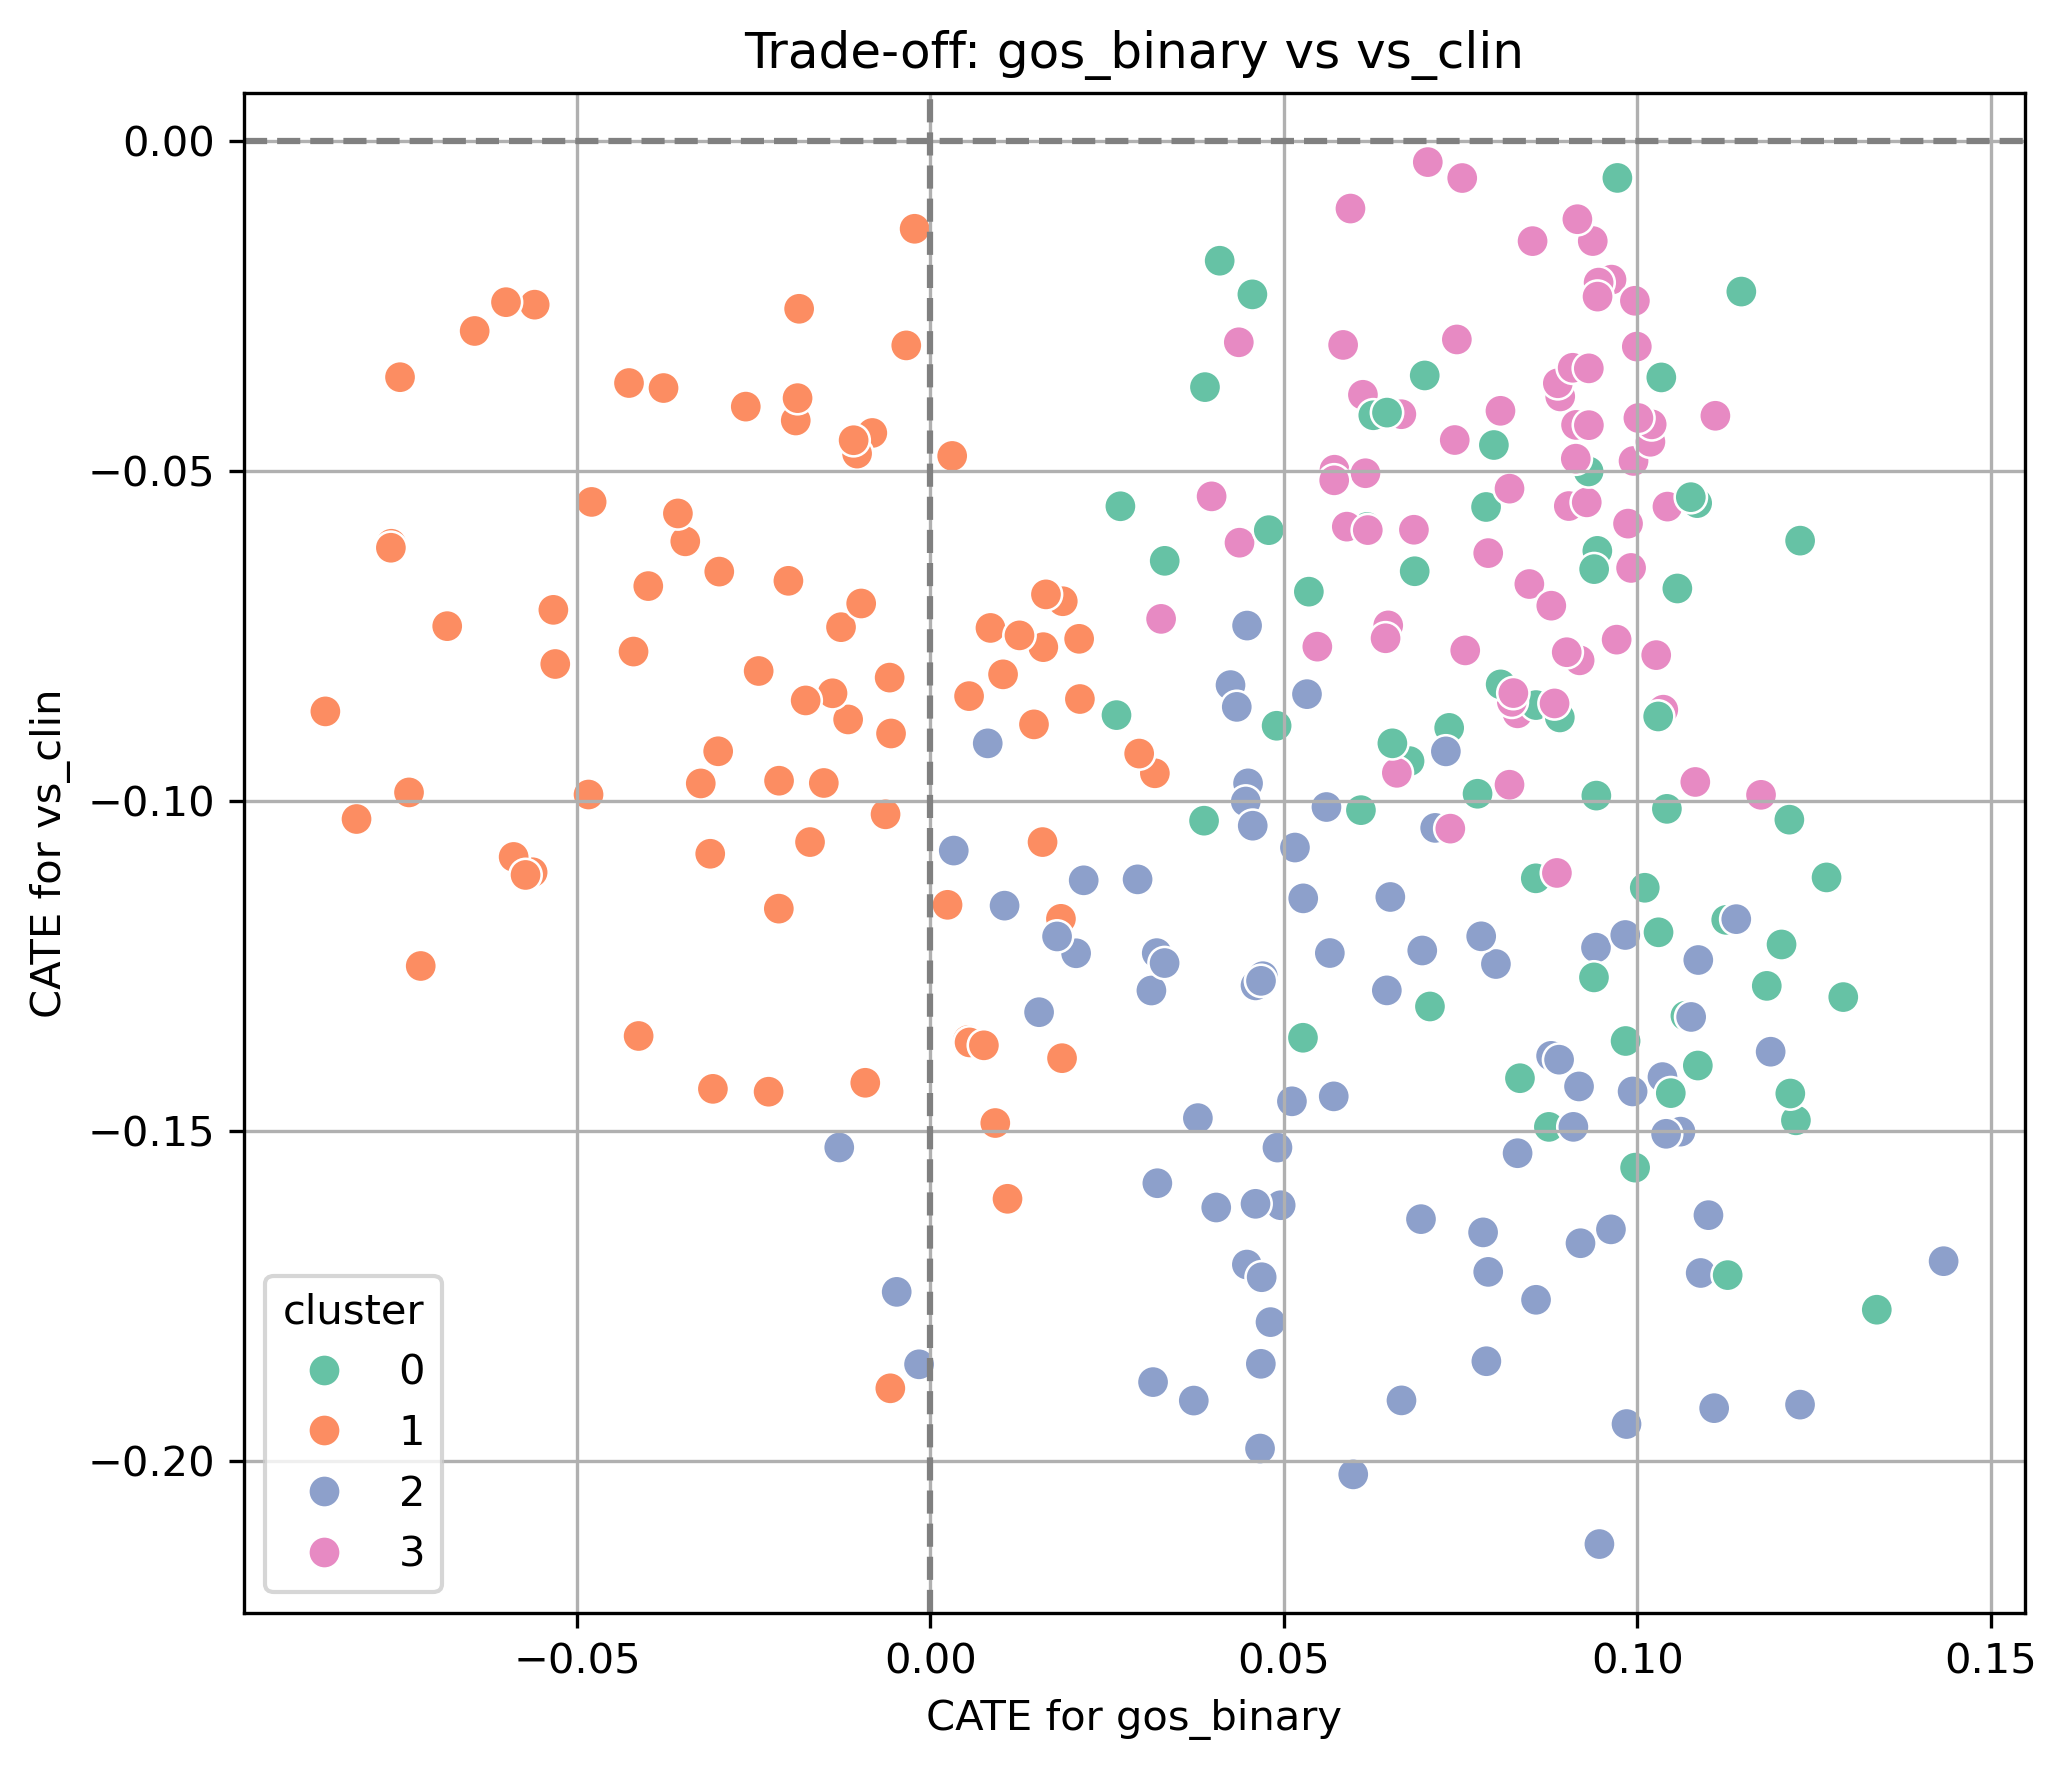

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cate_df = pd.DataFrame(cate_matrix, columns=cate_file_dict.keys())
cate_df['cluster'] = clusters

plot_cate_tradeoff(cate_df, "gos_binary", "vs_clin", clusters=cate_df['cluster'])
  

In [54]:
cate_df.columns

Index(['mrs_binary', 'infarct_dch', 'vs_clin', 'infection_dch', 'gos_binary',
       'shunt_180', 'cluster'],
      dtype='object')

In [49]:
vasospasm_df = pd.read_csv("vasospasm_data.csv")
vasospasm_df.columns

Index(['Unnamed: 0', 'no', 'random', 'age', 'sex', 'height', 'weight',
       'mrs_adm', 'gcs', 'hh', 'sedation_adm', 'aneurysm_no', 'aneurysm_trt',
       'infarct_trt', 'hemorrhage_trt', 'infarct_dch', 'rehab_dch',
       'barthel_dch', 'rehab_barthel_dch', 'mrs_dch', 'rehab_score_180',
       'barthel_180', 'rehab_barthel_180', 'mrs_180', 'gos8_180',
       'aneurysm_circulation', 'aneurysm_location', 'aneurysm_size',
       'hemorrh_before', 'paresis_adm', 'aphasia_adm', 'loc_dch',
       'infection_dch', 'gos8_dch', 'dch_imag_modality', 'shunt_dch',
       'shunt_180', 'nimodipine', 'statin', 'mg', 'vs_clin', 'vs_angio_amount',
       'vs_angio_trt_endo', 'query_180', 'evd_total', 'ld_total', 'csf_total',
       'tcd_max', 'center_size', 'wfns', 'ct_ivh', 'ct_ich', 'ct_origfisher',
       'ct_modfisher', 'days_sah_trt', 'days_sah_trt_ct', 'days_sah_icu',
       'days_trt_icu', 'days_sah_ld', 'days_angio_vs', 'days_sah_dch',
       'days_sah_dch_imaging', 'days_sah_death', 'days_tr

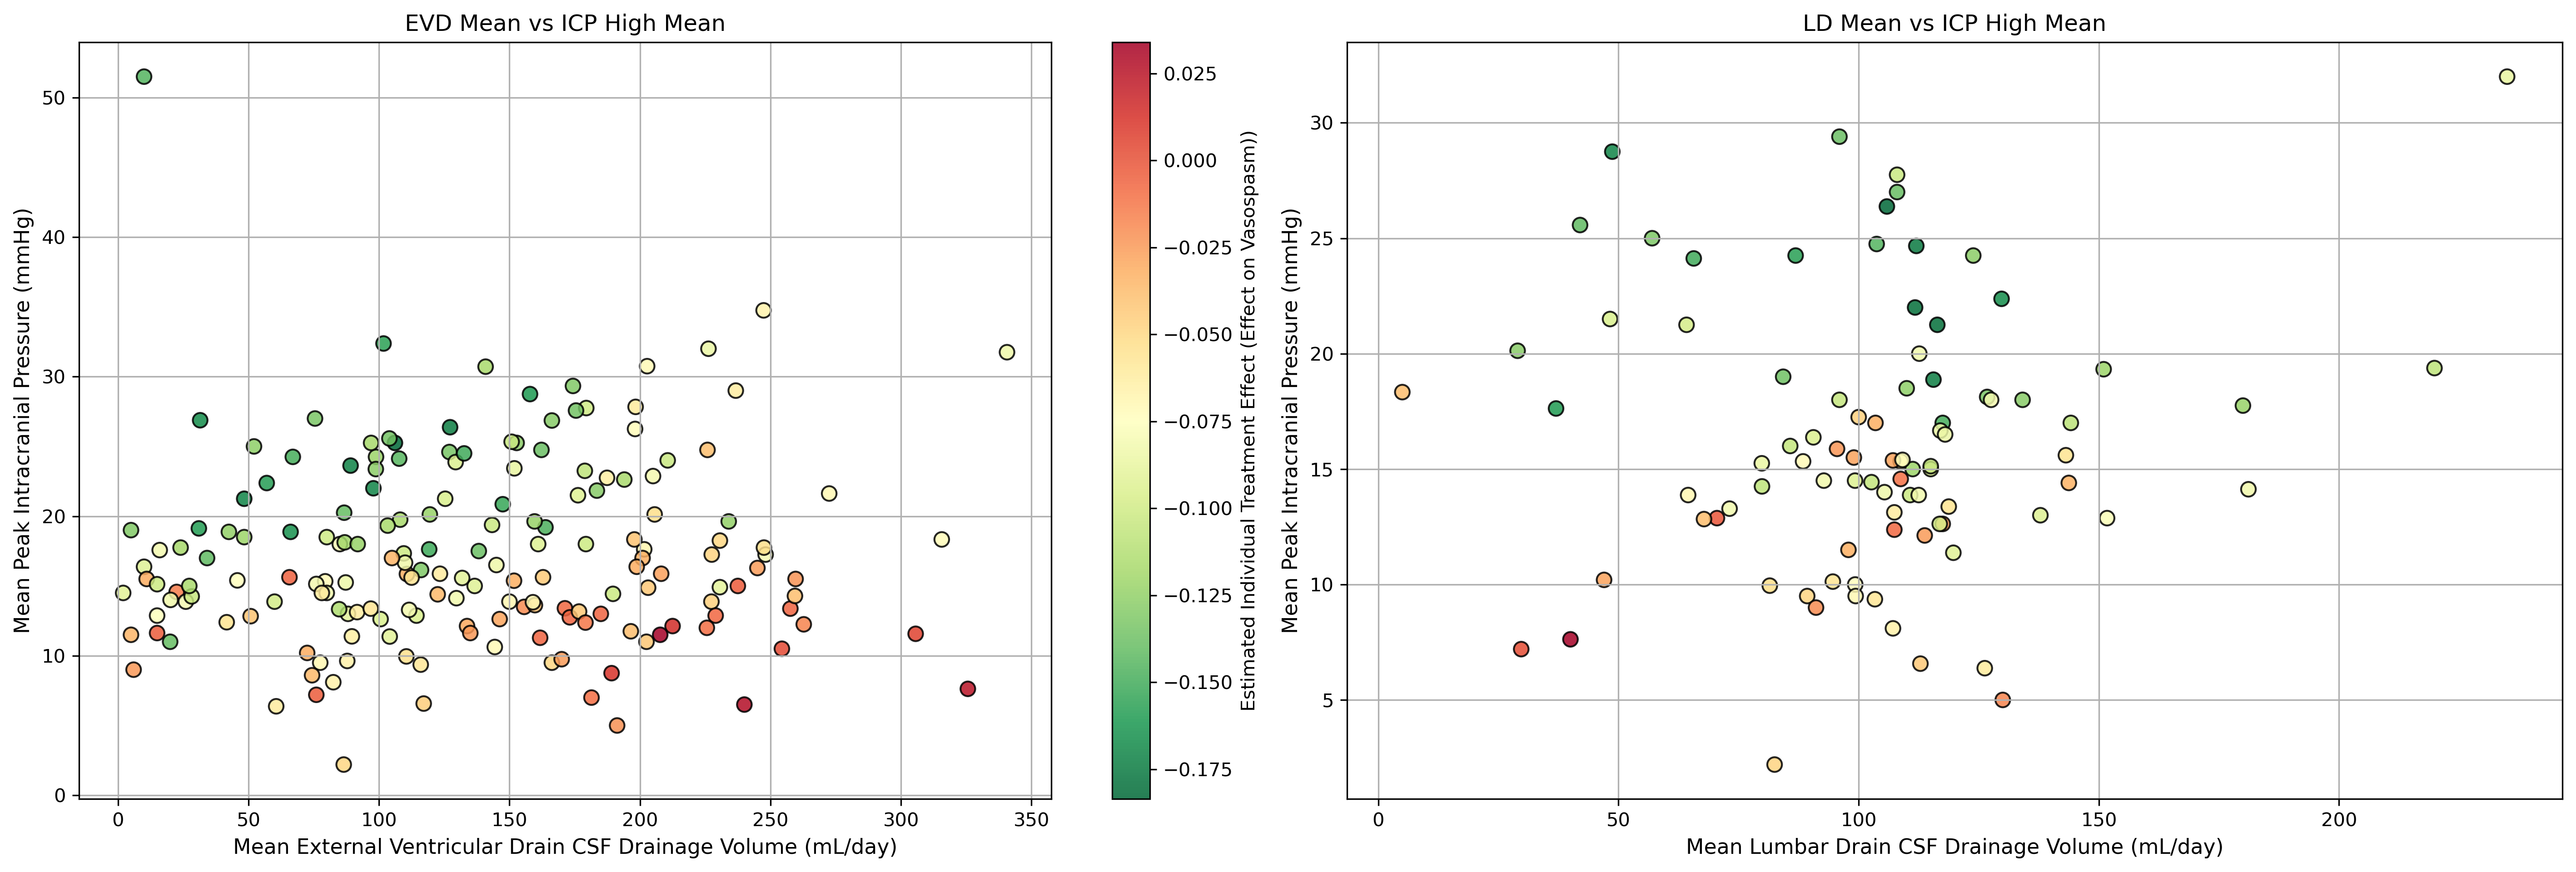

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine into one DataFrame
plot_df = vasospasm_df.copy()

plt.figure(figsize=(19, 6.5), dpi=300)
# First subplot: evd_mean vs icp_high_mean
plt.subplot(1, 2, 1)
sc = plt.scatter(
    plot_df['evd_mean'], 
    plot_df['icp_high_mean'], 
    c=plot_df['treatment_effect'], 
    cmap='RdYlGn_r',  # Green = benefit, Red = harm
    edgecolor='k',
    s=60,
    alpha=0.85
)
plt.xlabel("Mean External Ventricular Drain CSF Drainage Volume (mL/day)", fontsize=11)
plt.ylabel("Mean Peak Intracranial Pressure (mmHg)", fontsize=11)
plt.title("EVD Mean vs ICP High Mean")
plt.grid(True)

# Second subplot: ld_mean vs icp_high_mean
plt.subplot(1, 2, 2)
sc2 = plt.scatter(
    plot_df['ld_mean'], 
    plot_df['icp_high_mean'], 
    c=plot_df['treatment_effect'], 
    cmap='RdYlGn_r',
    edgecolor='k',
    s=60,
    alpha=0.85
)
plt.xlabel("Mean Lumbar Drain LD Volume (mL/day)", fontsize=11)
plt.ylabel("Mean Peak Intracranial Pressure (mmHg)", fontsize=11)
plt.title("LD Mean vs ICP High Mean")
plt.grid(True)

plt.tight_layout()
plt.colorbar(sc, label="Estimated Individual Treatment Effect (Effect on Vasospasm))")
plt.xlabel("Mean Lumbar Drain CSF Drainage Volume (mL/day)", fontsize=11)
plt.ylabel("Mean Peak Intracranial Pressure (mmHg)", fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()




C:\Users\shrin\AppData\Local\Temp\ipykernel_64240\1616108402.py:61: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



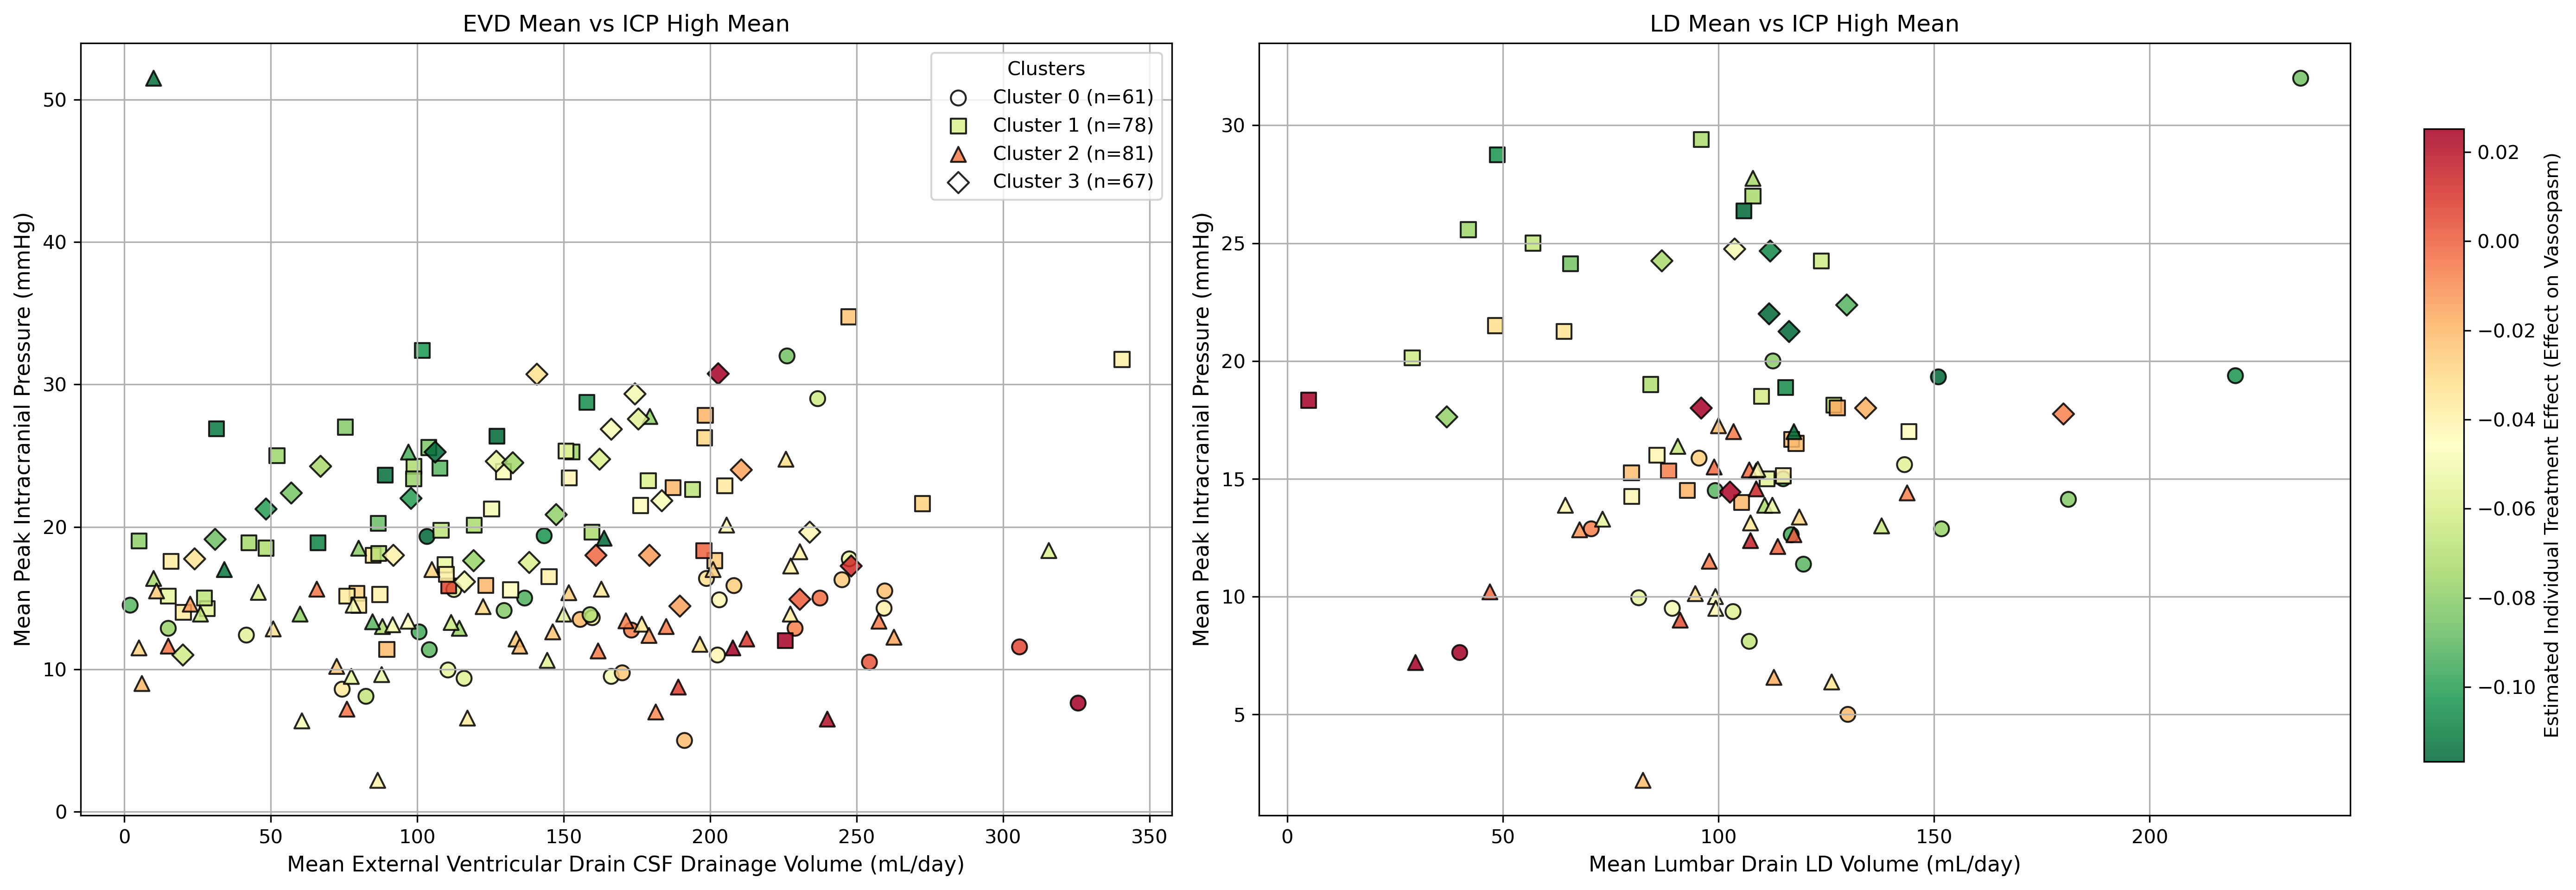

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# (your merging code stays the same...)

plot_df = vasospasm_df.copy()
plot_df['cluster'] = plot_df['cluster'].astype('category')

marker_map = ['o', 's', '^', 'D', 'P', 'X']
clusters = plot_df['cluster'].cat.categories.tolist()
marker_by_cluster = {cl: marker_map[i % len(marker_map)] for i, cl in enumerate(clusters)}

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(19, 6.5), dpi=300)

# Left subplot
handles = []
for cl in clusters:
    sub = plot_df[plot_df['cluster'] == cl]
    h = ax1.scatter(
        sub['evd_mean'], sub['icp_high_mean'],
        c=sub['treatment_effect'],
        cmap='RdYlGn_r',
        edgecolor='k', s=60, alpha=0.85,
        marker=marker_by_cluster[cl],
        label=f"Cluster {cl} (n={len(sub)})"
    )
    handles.append(h)

ax1.set_xlabel("Mean External Ventricular Drain CSF Drainage Volume (mL/day)", fontsize=11)
ax1.set_ylabel("Mean Peak Intracranial Pressure (mmHg)", fontsize=11)
ax1.set_title("EVD Mean vs ICP High Mean")
ax1.grid(True)

# Right subplot
for cl in clusters:
    sub = plot_df[plot_df['cluster'] == cl]
    ax2.scatter(
        sub['ld_mean'], sub['icp_high_mean'],
        c=sub['treatment_effect'],
        cmap='RdYlGn_r',
        edgecolor='k', s=60, alpha=0.85,
        marker=marker_by_cluster[cl]
    )

ax2.set_xlabel("Mean Lumbar Drain LD Volume (mL/day)", fontsize=11)
ax2.set_ylabel("Mean Peak Intracranial Pressure (mmHg)", fontsize=11)
ax2.set_title("LD Mean vs ICP High Mean")
ax2.grid(True)

# --- Place colorbar neatly on the right side ---
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
fig.colorbar(handles[0], cax=cbar_ax,
             label="Estimated Individual Treatment Effect (Effect on Vasospasm)")

# Legend
ax1.legend(title="Clusters", loc='best', frameon=True)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for the colorbar
plt.show()
